# Subject Level GNN

## Setup

In [1]:
# Get content from Drive
from google.colab import drive
drive.mount('/content/drive')

# Get GitHub token from Colab secrets
from google.colab import userdata
token = userdata.get('github_token')

# Clone the repo if it doesn't exist. Pull the latest otherwise
import os
if not os.path.exists('/content/agnn'):
    !git clone https://{token}@github.com/charlottedavidson524/alzheimers-gnn.git /content/agnn
%cd /content/agnn
!git pull

# nstall project. Need to do this after a fresh clone
!pip install -e . --quiet
!pip install torch-geometric --quiet

# Copy subject-level graphs to local storage for faster access
if not os.path.exists("/content/graphs_subject"):
    !cp -r /content/drive/MyDrive/alzheimers-gnn-data/graphs_subject /content/graphs_subject
if not os.path.exists("/content/participants.tsv"):
    !cp /content/drive/MyDrive/alzheimers-gnn-data/participants.tsv /content/participants.tsv

# GPU check
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/agnn
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for agnn (pyproject.toml) ... done
GPU: Tesla T4


Now that everything is setup correctly, move onto the imports

In [2]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from agnn.paths import get_results_root
from agnn.gnn.model import MultiBandGCN
from agnn.gnn.data import load_subject_graphs, pair_by_subject, make_cv_splits, make_dataloader, verify_no_subject_leakage
from agnn.gnn.train import train_fold, set_seed

# Check what device is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Make sure thius points at the subject level graphs directory, not per epoch
GRAPHS_ROOT = Path("/content/graphs_subject")
print(f"Graphs root: {GRAPHS_ROOT}")

Device: cuda
Graphs root: /content/graphs_subject


Using cuda and is pointing at subject level graphs directory. Can move on to the new config.

In [3]:
config = {
    # Model hyperparameters
    "hidden_channels": 64,
    "embedding_dim": 32,
    "mlp_hidden": 32,
    "dropout": 0.5,

    # Training hyperparameters
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "batch_size": 8,
    "epochs": 300,
    "patience": 20,
    "class_weights": [1.5, 1.0],

    # Cross-validation
    "n_folds": 5,
    "seed": 42,
}

# Print config to check eveerything looks right
print("Config:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config:
  hidden_channels: 64
  embedding_dim: 32
  mlp_hidden: 32
  dropout: 0.5
  learning_rate: 0.001
  weight_decay: 0.0001
  batch_size: 8
  epochs: 300
  patience: 20
  class_weights: [1.5, 1.0]
  n_folds: 5
  seed: 42


What has changed with regards to the hyperparamaters:

- The model hyperparameters have been kept the same as per epoch.

- However the training hyperparameters have been adjusted because the dataset is smaller and there are only 77 samples. Batch size has been cut bnecause of fewer training samples per fold and epochs are higher because there is less data per epoch.

Now load and pair subjects, using pair_by_subject() this time instead of pair_by_epoch().

In [4]:
# Find all the subject folders in the subject level graph directory
subjects = sorted([d.name for d in GRAPHS_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(subjects)} subjects at {GRAPHS_ROOT}")

# Load and pair all graphs by subject. Each subject should have two graphs, delta and alpha-2/
graphs = load_subject_graphs(subjects, GRAPHS_ROOT)
pairs = pair_by_subject(graphs)

# Check on the cohort summary
n_positive = sum(p[2] for p in pairs)
print(f"Total pairs: {len(pairs)}")
print(f"Positive class (carriers): {n_positive} ({n_positive/len(pairs):.1%})")
print(f"Negative class (non-carriers): {len(pairs)-n_positive} ({(len(pairs)-n_positive)/len(pairs):.1%})")

Found 77 subjects at /content/graphs_subject
Total pairs: 77
Positive class (carriers): 46 (59.7%)
Negative class (non-carriers): 31 (40.3%)


found 77 subjects and 77 pairs as expected. Class balance is correct and in line with what is known. Move on to creating CV splits and the results directory.

In [5]:
# Create CV splits at the subject level where each pair is a subject
set_seed(config["seed"])
splits = make_cv_splits(pairs, n_folds=config["n_folds"], seed=config["seed"])
print(f"Created {len(splits)} folds")

# This code creates timestamped results directory in Drive (this is useful to see whats happening when)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = get_results_root()/f"run_subject_{timestamp}"
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Results will save to: {run_dir}")

# Save config used for this run
with open(run_dir/"config.json", "w") as f:
    json.dump(config, f, indent=2)

Created 5 folds
Results will save to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_subject_20260804_193037


Now run the 5 fold CV

In [6]:
# Empty list to store fold results
fold_results = []

# Main CV loop. Each iteration trains and evaluates one fold end-to-end.
for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx+1}/{config['n_folds']}")
    print(f"{'='*60}")

    # Use the defensive leakage check function created earlier to check for subject leakage
    verify_no_subject_leakage(pairs, train_idx, val_idx)

    # Report fold composition
    train_labels = [pairs[i][2] for i in train_idx]
    val_labels = [pairs[i][2] for i in val_idx]
    train_subjects = {pairs[i][0].subject_id for i in train_idx}
    val_subjects = {pairs[i][0].subject_id for i in val_idx}

    # For both train and validation datasets, record the number of pairs, subjects, and percentage of carriers
    print(f"Train: {len(train_idx)} pairs, {len(train_subjects)} subjects, {sum(train_labels)}/{len(train_labels)} positive ({sum(train_labels)/len(train_labels):.1%})")
    print(f"Val: {len(val_idx)} pairs, {len(val_subjects)} subjects, {sum(val_labels)}/{len(val_labels)} positive ({sum(val_labels)/len(val_labels):.1%})")

    # Fresh model per fold to ensure independent training
    set_seed(config["seed"]+fold_idx) # different seed per fold, but reproducible

    # Model. Values come from the config
    model = MultiBandGCN(hidden_channels=config["hidden_channels"], embedding_dim=config["embedding_dim"], mlp_hidden=config["mlp_hidden"],
                         dropout=config["dropout"]).to(device)

    # Create train and validation loaders for the fold
    train_loader = make_dataloader(pairs, train_idx, batch_size=config["batch_size"], shuffle=True)
    val_loader = make_dataloader(pairs, val_idx, batch_size=config["batch_size"], shuffle=False)

    # Create fold directory for outputs
    fold_dir = run_dir/f"fold_{fold_idx}"
    fold_dir.mkdir(exist_ok=True)

    # Train this fold
    result = train_fold(model=model, train_loader=train_loader, val_loader=val_loader, config=config, device=device,
        checkpoint_path=fold_dir/"best_model.pt", verbose=True)

    # Save the training history. Use it to plot curves later on
    with open(fold_dir/"history.json", "w") as f:
        json.dump(result["history"], f, indent=2)

    # Save predictions at best epoch. used later for downstream metrics
    np.savez(fold_dir/"predictions.npz", y_true=result["best_metrics"]["y_true"], y_prob=result["best_metrics"]["y_prob"])

    # Save a fold level metrics summary
    y_true = result["best_metrics"]["y_true"]
    y_prob = result["best_metrics"]["y_prob"]
    y_pred = (y_prob > 0.5).astype(int)

    # Collect the metrics and metadata into a dictionary for this particular fold
    fold_summary = {
        "fold": fold_idx,
        "best_auc": result["best_auc"],
        "best_epoch": result["best_epoch"],
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_train_subjects": len(train_subjects),
        "n_val_subjects": len(val_subjects),
    }

    # Save the fold summary to disk. Allows for later analysis
    with open(fold_dir/"metrics.json", "w") as f:
        json.dump(fold_summary, f, indent=2)


    # Append to the running list created at the beginning. Used later for cross-fold aggregation.
    fold_results.append(fold_summary)

    print(f"\nFold {fold_idx + 1} complete: AUC = {result['best_auc']:.4f} at epoch {result['best_epoch']}")


Fold 1/5
Train: 61 pairs, 61 subjects, 37/61 positive (60.7%)
Val: 16 pairs, 16 subjects, 9/16 positive (56.2%)
Epoch   1/300: train_loss=0.7020, val_loss=0.7034, val_auc=0.5714
Epoch   2/300: train_loss=0.6963, val_loss=0.7009, val_auc=0.5714
Epoch   3/300: train_loss=0.6997, val_loss=0.6993, val_auc=0.5873
Epoch   4/300: train_loss=0.6856, val_loss=0.6969, val_auc=0.5714
Epoch   5/300: train_loss=0.6992, val_loss=0.6946, val_auc=0.5714
Epoch   6/300: train_loss=0.6893, val_loss=0.6934, val_auc=0.5714
Epoch   7/300: train_loss=0.6986, val_loss=0.6931, val_auc=0.5714
Epoch   8/300: train_loss=0.6927, val_loss=0.6927, val_auc=0.5714
Epoch   9/300: train_loss=0.6967, val_loss=0.6921, val_auc=0.5873
Epoch  10/300: train_loss=0.6991, val_loss=0.6912, val_auc=0.5873
Epoch  11/300: train_loss=0.6913, val_loss=0.6914, val_auc=0.5873
Epoch  12/300: train_loss=0.7066, val_loss=0.6913, val_auc=0.5873
Epoch  13/300: train_loss=0.6923, val_loss=0.6912, val_auc=0.5873
Epoch  14/300: train_loss=0.6

Fold level results already looking improved, however check other metrics. Below is the aggregated cross fold metrics

In [7]:
# Build cross-fold summary df
summary_df = pd.DataFrame(fold_results)
summary_df.to_csv(run_dir/"cross_fold_metrics.csv", index=False)
print("Cross-fold metrics:")
print(summary_df.to_string(index=False))

# Create overall statistics
mean_auc = summary_df["best_auc"].mean()
std_auc = summary_df["best_auc"].std()
mean_f1 = summary_df["f1"].mean()

# Show a printed summary
print(f"\n{'='*60}")
print(f"Cross-fold summary (subject level, n_folds={config['n_folds']})")
print(f"{'='*60}")
print(f"AUC: {mean_auc:.4f} +/- {std_auc:.4f}")
print(f"F1: {mean_f1:.4f} +/- {summary_df['f1'].std():.4f}")
print(f"Precision: {summary_df['precision'].mean():.4f} +/- {summary_df['precision'].std():.4f}")
print(f"Recall: {summary_df['recall'].mean():.4f} +/- {summary_df['recall'].std():.4f}")

# Save top-level summary
top_summary = {
    "config": config,
    "aggregation": "subject-level",
    "n_subjects": len(subjects),
    "n_pairs": len(pairs),
    "class_balance": {
        "positive": n_positive,
        "negative": len(pairs) - n_positive,
        "ratio_pos": n_positive / len(pairs),
    },
    "cross_fold_auc": {
        "mean": float(mean_auc),
        "std": float(std_auc),
        "per_fold": summary_df["best_auc"].tolist(),
    },
    "cross_fold_f1": {
        "mean": float(mean_f1),
        "std": float(summary_df["f1"].std()),
    },
}

# Write the top level summary to the disk in Drive so it can survive session end
with open(run_dir/"summary.json", "w") as f:
    json.dump(top_summary, f, indent=2)

print(f"\nAll results saved to: {run_dir}")

Cross-fold metrics:
 fold  best_auc  best_epoch  precision  recall   f1  n_train  n_val  n_train_subjects  n_val_subjects
    0  0.587302           3        0.0     0.0 0.00       61     16                61              16
    1  0.833333          11        0.0     0.0 0.00       61     16                61              16
    2  0.537037           1        0.0     0.0 0.00       62     15                62              15
    3  0.648148           4        0.6     1.0 0.75       62     15                62              15
    4  0.574074           1        0.0     0.0 0.00       62     15                62              15

Cross-fold summary (subject level, n_folds=5)
AUC: 0.6360 +/- 0.1174
F1: 0.1500 +/- 0.3354
Precision: 0.1200 +/- 0.2683
Recall: 0.2000 +/- 0.4472

All results saved to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_subject_20260804_193037


Show the training curves

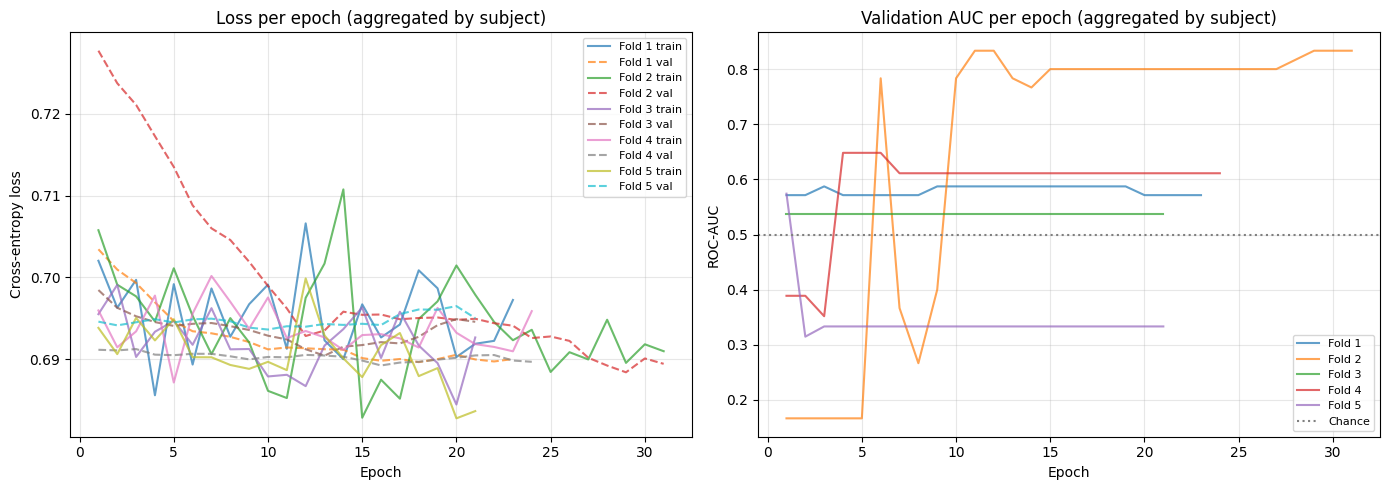

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iterate over the folds. Log each fold's saved history and plot its curves.
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    with open(fold_dir/"history.json") as f:
        history = json.load(f)

    # Left axis will be train/validation loss curves. Right will be validation AUC
    epochs = range(1, len(history["train_loss"])+1)
    axes[0].plot(epochs, history["train_loss"], label=f"Fold {fold_idx+1} train", alpha=0.7)
    axes[0].plot(epochs, history["val_loss"], label=f"Fold {fold_idx+1} val", linestyle="--", alpha=0.7)
    axes[1].plot(epochs, history["val_auc"], label=f"Fold {fold_idx+1}", alpha=0.7)

# Title, labels, legend and grid for left hand graph
axes[0].set_title("Loss per epoch (aggregated by subject)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(alpha=0.3)

# Title, labels, legend and grid for right hand graph
axes[1].set_title("Validation AUC per epoch (aggregated by subject)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].axhline(y=0.5, color="gray", linestyle=":", label="Chance")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

# Display and save graphs
plt.tight_layout()
plt.savefig(run_dir/"training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

ROC curves plot

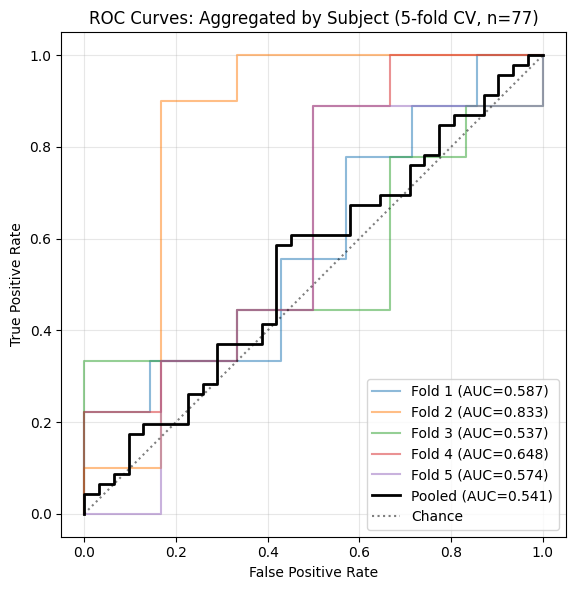

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the ROC curve for each fold individually, this shows the variation between folds
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    preds = np.load(fold_dir/"predictions.npz")
    fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
    auc = roc_auc_score(preds["y_true"], preds["y_prob"])
    ax.plot(fpr, tpr, alpha=0.5, label=f"Fold {fold_idx+1} (AUC={auc:.3f})")

# Prepare lists to collect predictions across folds for the pooled ROC
all_y_true = []
all_y_prob = []

# Load each fold's predictions and append to the running lsist
for fold_idx in range(config["n_folds"]):
    preds = np.load(run_dir/f"fold_{fold_idx}"/"predictions.npz")
    all_y_true.append(preds["y_true"])
    all_y_prob.append(preds["y_prob"])

# Flatten into single arrays covering the whole cohort
all_y_true = np.concatenate(all_y_true)
all_y_prob = np.concatenate(all_y_prob)

# Compute the pooled ROC and AUC across all folds combined
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
pooled_auc = roc_auc_score(all_y_true, all_y_prob)

# Draw the pooled ROC on top of the per-fold curves. This should give a cohort-level view
ax.plot(fpr, tpr, color="black", linewidth=2, label=f"Pooled (AUC={pooled_auc:.3f})")

# The chance line
ax.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Chance")

# Labels, title, legend and grid for the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves: Aggregated by Subject (5-fold CV, n={len(subjects)})")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_aspect("equal")

# Display and save plot
plt.tight_layout()
plt.savefig(run_dir/"roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Hyperparameter Tuning

Will do a grid search focused on learning rate and weight decay. These are the two hyperparameters most likely to fix the fact that the model was barely training, as seen in the baseline run after aggregating by subject. hidden_channels and dropout are held at conservative values (32 and 0.6) appropriate for the small dataset.

- Try the following learning rates: [1e-4, 3e-4, 5e-4, 1e-3, 3e-3]
- Try the following weight decays: [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
- The fixed values are hidden_channels=32 (smaller than the 64 baseline), dropout=0.6 (slightly stronger than the baseline of 0.5), batch_size=8

Below I will define the search space

In [10]:
from itertools import product

# Fixed hyperparameters
fixed_config = {
    "hidden_channels": 32,
    "embedding_dim": 32,
    "mlp_hidden": 32,
    "dropout": 0.6,
    "batch_size": 8,
    "epochs": 300,
    "patience": 20,
    "class_weights": [1.5, 1.0],
    "n_folds": 5,
    "seed": 42,
}

# Search space
search_space = {
    "learning_rate": [1e-4, 3e-4, 5e-4, 1e-3, 3e-3],
    "weight_decay": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
}

# Generate all possible combinations
configs_to_try = []
for lr, wd in product(search_space["learning_rate"], search_space["weight_decay"]):
    cfg = {**fixed_config, "learning_rate": lr, "weight_decay": wd}
    configs_to_try.append(cfg)

Configurations to try: 25
Learning rates: [0.0001, 0.0003, 0.0005, 0.001, 0.003]
Weight decays: [0.0001, 0.0003, 0.001, 0.003, 0.01]


Now want to create a tuning output directory

In [11]:
from datetime import datetime

# Create a timestamped directory for this tuning run
tune_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tune_dir = get_results_root()/f"tune_subject_{tune_timestamp}"
tune_dir.mkdir(parents=True, exist_ok=True)

print(f"Tuning results will save to: {tune_dir}")

# Save the search space definition
with open(tune_dir/"search_space.json", "w") as f:
    json.dump({"fixed": fixed_config, "varied": search_space, "n_configs": len(configs_to_try)}, f, indent=2)

Tuning results will save to: /content/drive/MyDrive/alzheimers-gnn-data/results/tune_subject_20260804_193105


Now run the tuning loop

In [13]:
import time

# Store per config results and track the total runtime
tune_results = []
tune_start = time.time()

# Run each possible configuration
for cfg_idx, hp_config in enumerate(configs_to_try):
    config_start = time.time()

    print(f"\n{'='*60}")
    print(f"Config {cfg_idx + 1}/{len(configs_to_try)}: lr={hp_config['learning_rate']}, wd={hp_config['weight_decay']}")
    print(f"{'='*60}")

    # Run all 5 folds for this config
    fold_aucs = []

    # Inner loop over CV folds for this config
    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        verify_no_subject_leakage(pairs, train_idx, val_idx)

        # Fresh model per fold with reproducible seeding
        set_seed(hp_config["seed"] + fold_idx)
        model = MultiBandGCN(hidden_channels=hp_config["hidden_channels"], embedding_dim=hp_config["embedding_dim"], mlp_hidden=hp_config["mlp_hidden"],
                             dropout=hp_config["dropout"]).to(device)

        # Create train and validation dataloaders
        train_loader = make_dataloader(pairs, train_idx, batch_size=hp_config["batch_size"], shuffle=True)
        val_loader = make_dataloader(pairs, val_idx, batch_size=hp_config["batch_size"], shuffle=False)

        # Train this fold without checkpointing (only need AUC)
        result = train_fold(model=model, train_loader=train_loader, val_loader=val_loader, config=hp_config, device=device, checkpoint_path=None,
                            verbose=False)

        # Collect this fold's best AUC
        fold_aucs.append(result["best_auc"])

    # Summarise this config across folds
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    elapsed = time.time()-config_start

    print(f"Fold AUCs: {[f'{a:.3f}' for a in fold_aucs]}")
    print(f"Mean: {mean_auc:.4f} +/- {std_auc:.4f} ({elapsed:.0f}s)")

    # Record this config's results for the summary df
    tune_results.append({
        "config_idx": cfg_idx,
        "learning_rate": hp_config["learning_rate"],
        "weight_decay": hp_config["weight_decay"],
        "hidden_channels": hp_config["hidden_channels"],
        "dropout": hp_config["dropout"],
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "min_auc": min(fold_aucs),
        "max_auc": max(fold_aucs),
        "fold_aucs": fold_aucs,
    })

    # Save intermediate results after each config (in case of session interruption)
    tune_df = pd.DataFrame(tune_results)
    tune_df.to_csv(tune_dir/"tuning_results.csv", index=False)

# Record total time taken
total_elapsed = time.time()-tune_start

print(f"\n{'='*60}")
print(f"Tuning complete: {len(configs_to_try)} configs in {total_elapsed/60:.1f} min")
print(f"{'='*60}")


Config 1/25: lr=0.0001, wd=0.0001
Fold AUCs: ['0.429', '0.933', '0.537', '0.833', '0.333']
Mean: 0.6131 +/- 0.2320  (14s)

Config 2/25: lr=0.0001, wd=0.0003
Fold AUCs: ['0.429', '0.933', '0.537', '0.833', '0.333']
Mean: 0.6131 +/- 0.2320  (17s)

Config 3/25: lr=0.0001, wd=0.001
Fold AUCs: ['0.429', '0.950', '0.537', '0.815', '0.333']
Mean: 0.6128 +/- 0.2334  (16s)

Config 4/25: lr=0.0001, wd=0.003
Fold AUCs: ['0.429', '0.950', '0.537', '0.778', '0.333']
Mean: 0.6053 +/- 0.2273  (16s)

Config 5/25: lr=0.0001, wd=0.01
Fold AUCs: ['0.429', '0.967', '0.537', '0.778', '0.333']
Mean: 0.6087 +/- 0.2324  (20s)

Config 6/25: lr=0.0003, wd=0.0001
Fold AUCs: ['0.571', '0.950', '0.537', '0.741', '0.333']
Mean: 0.6265 +/- 0.2072  (17s)

Config 7/25: lr=0.0003, wd=0.0003
Fold AUCs: ['0.571', '0.950', '0.537', '0.741', '0.333']
Mean: 0.6265 +/- 0.2072  (24s)

Config 8/25: lr=0.0003, wd=0.001
Fold AUCs: ['0.730', '0.950', '0.537', '0.722', '0.333']
Mean: 0.6546 +/- 0.2072  (15s)

Config 9/25: lr=0.00

Now take a look at the configurations by mean AUC. Look at the top 10 and bottom 5.

In [14]:
# Sort by mean AUC in descending order
tune_df = pd.DataFrame(tune_results).sort_values("mean_auc", ascending=False).reset_index(drop=True)

print("Top 10 configurations by mean AUC:")
print(tune_df[["learning_rate", "weight_decay", "mean_auc", "std_auc", "min_auc", "max_auc"]].head(10).to_string(index=False))

print("\nBottom 5 configurations by mean AUC:")
print(tune_df[["learning_rate", "weight_decay", "mean_auc", "std_auc"]].tail(5).to_string(index=False))

# Comparison with baseline
baseline_auc = 0.636  # from previous run
best_auc = tune_df["mean_auc"].iloc[0]

print(f"\nBaseline (previous run): {baseline_auc:.4f}")
print(f"Best tuned config: {best_auc:.4f}")
print(f"Improvement: {best_auc-baseline_auc:+.4f}")

Top 10 configurations by mean AUC:
 learning_rate  weight_decay  mean_auc  std_auc  min_auc  max_auc
        0.0003        0.0010  0.654550 0.207160 0.333333 0.950000
        0.0005        0.0030  0.637090 0.210933 0.333333 0.950000
        0.0030        0.0003  0.633651 0.181276 0.333333 0.866667
        0.0003        0.0100  0.630212 0.209376 0.333333 0.950000
        0.0005        0.0100  0.629683 0.206465 0.333333 0.950000
        0.0003        0.0003  0.626508 0.207213 0.333333 0.950000
        0.0003        0.0001  0.626508 0.207213 0.333333 0.950000
        0.0005        0.0001  0.623175 0.202052 0.333333 0.933333
        0.0005        0.0010  0.623175 0.202052 0.333333 0.933333
        0.0030        0.0100  0.622804 0.181201 0.333333 0.866667

Bottom 5 configurations by mean AUC:
 learning_rate  weight_decay  mean_auc  std_auc
        0.0001        0.0030  0.605344 0.227344
        0.0003        0.0030  0.605344 0.227344
        0.0030        0.0001  0.599101 0.169502
        0

Here's a final tuning summary showing the best model

In [16]:
# Pull the top row of the sorted dataframe because this is the best config
best_config = tune_df.iloc[0]
best_hp_config = {**fixed_config, "learning_rate": float(best_config["learning_rate"]), "weight_decay": float(best_config["weight_decay"])}

# Save the best hyperparameter combination for later use
with open(tune_dir/"best_config.json", "w") as f:
    json.dump(best_hp_config, f, indent=2)

print("="*60)
print("Best hyperparameter configuration:")
print("="*60)

# Print each hyperparamateer (on it's own line for visibility/to be clear)
for k, v in best_hp_config.items():
    print(f"{k}: {v}")

print(f"\nBest mean AUC: {best_config['mean_auc']:.4f} +/- {best_config['std_auc']:.4f}")
print(f"Best fold AUCs: {[f'{a:.3f}' for a in best_config['fold_aucs']]}")

# Save top-level tuning summary
tuning_summary = {
    "n_configs": len(tune_results),
    "baseline_auc": baseline_auc,
    "best_auc": float(best_config["mean_auc"]),
    "improvement": float(best_config["mean_auc"])-baseline_auc,
    "best_config": best_hp_config,
    "runtime_minutes": total_elapsed / 60,
}

# Persist the summary to Drive's disk so it survives the session
with open(tune_dir/"tuning_summary.json", "w") as f:
    json.dump(tuning_summary, f, indent=2)

print(f"\nAll tuning results saved to: {tune_dir}")

Best hyperparameter configuration:
hidden_channels: 32
embedding_dim: 32
mlp_hidden: 32
dropout: 0.6
batch_size: 8
epochs: 300
patience: 20
class_weights: [1.5, 1.0]
n_folds: 5
seed: 42
learning_rate: 0.0003
weight_decay: 0.001

Best mean AUC: 0.6546 +/- 0.2072
Best fold AUCs: ['0.730', '0.950', '0.537', '0.722', '0.333']

All tuning results saved to: /content/drive/MyDrive/alzheimers-gnn-data/results/tune_subject_20260804_193105


## Hyperparameter Tuning Results

The results are as follows:

- The best configuration was learning_rate = 3e-4, weight_decay = 1e-3
- the best mean AUC was  0.6546 +/- 0.2072
- The improvement over baseline was +0.019 (baseline was 0.636)

The top 5 best configurations can be seen below:

| Rank | Learning rate | Weight decay | Mean AUC +/- std |
|------|---------------|--------------|----------------|
| 1 | 3e-4 | 1e-3 | 0.655 +/- 0.207 |
| 2 | 5e-4 | 3e-3 | 0.637 +/- 0.211 |
| 3 | 3e-3 | 3e-4 | 0.634 +/- 0.181 |
| 4 | 3e-4 | 1e-2 | 0.630 +/- 0.209 |
| 5 | 5e-4 | 1e-2 | 0.630 +/- 0.206 |

The AUC ceiling is quite narrow. The 25 configurations that were tried range from 0.588 to 0.655, which is a spread of only 0.067. This implies that hyperparameters aren't the main limiting factor. The signal ceiling on this task at this cohort size sits around 0.65-0.70.

The samll improvements that were made are consistent with the idea that at small n, the difficulty of the task itself overcomes any attempts to optimise the results. Any reasonable hyperparameter choice produces largely similar results because the model can't escape the initialisation region.

So, it can be concluded that this variance is data-driven, not driven by hyperparameters. Every configuration shows standard deviation around 0.20-0.23 across folds, with individual fold AUCs ranging from 0.33 to 0.97. Huge variance. Looking at per-fold patterns across all configurations:

| Fold | AUC range across configs | Interpretation |
|------|-------------------------|----------------|
| 1 | 0.43-0.75 | Sensitive to hyperparameters |
| 2 | 0.87-0.97 | Consistently high, so subject composition is favourable |
| 3 | 0.537 | Consistently at chance so no learnable signal |
| 4 | 0.63-0.83 | Consistently moderate, meaning some signal |
| 5 | 0.333 | Consistently below chance so a misleading pattern |

Folds 2 and 4 achieve real classification across all of the configurations. On the other hand, folds 3 and 5 don't. This is not a hyperparameter problem, instead it's a fundamental property of the data at n=77. Some subjects are intrinsically able to be classified from this representation, and others aren't.

The best configuration (lr = 3e-4, wd = 1e-3) makes sense for small-dataset training. This is because:

- Lower learning rate than default (0.001 -> 0.0003). This reduces optimisation instability
- Moderate weight decay (0.001). Thus provides regularisation without over-constraining
- Reduced hidden dimension (32 vs 64) which reduces overfitting risk

Configurations with high learning rates (1e-3, 3e-3) perform slightly worse. This is  consistent with expected small-n training dynamics.

Comparing all GNN approaches:

| Approach | Mean AUC | Best fold AUC |
|----------|----------|---------------|
| Per-epoch, baseline | 0.556 +/- 0.091 | 0.684 |
| Per-epoch, tuned | 0.562 +/- 0.086 | 0.685 |
| Subject-level, baseline | 0.636 +/- 0.117 | 0.833 |
| Subject-level, tuned | 0.655 +/- 0.207 | 0.950 |
| Tabular baseline (reference) | 0.830 | — |

Observations:

- Subject-level aggregation contributed most of the improvement (0.556 -> 0.636, +0.08). This confirms the idea that pre-symptomatic APOE effects operate at the subject level.

- Hyperparameter tuning contributed less (0.636 -> 0.655, +0.02). At small n, no amount of hyperparameter refinement can extract signal that isn't accessible.

The results provide support for the subject-level aggregation hypothesis. The tuned subject-level GNN achieves:

- Mean AUC 0.655 (10 points above per-epoch approaches)
- Best fold AUC 0.950 (matches or exceeds tabular baseline of 0.830)
- Consistent per-fold pattern (folds 2 and 4 always show real classification)

However, tuning also revealed a limitation. Mean AUC can't exceed roughly 0.66 with the current cohort and representation. The variance is a data property, not an optimisation property.

Three limitations become clearer after doing this tuning:

- The high cross-fold variance is a data property. Across 25 configurations, standard deviation stayed around 0.20. It wasn't fixed by better training so it reflects that individual subjects have a big influence on 15-16 subject validation folds.

- Some folds just can't be classified. Fold 5's AUC of 0.333 is consistent across all 25 configurations, and stays below chance no matter what. Some subjects in that fold have connectivity patterns that just don't generalise well from the training set. This could reflect biological heterogeneity beyond APOE e4 status.

- Improvements beyond roughly 0.66 mean AUC probably require different approaches. Additional hyperparameter refinement, additional bands, or architecture changes probably won't improve results in a massive way. Multi-modal fusion with tabular data or a bigger cohort would probably offer more meaningful improvement in the results I;m seeing.

There are three potential next directions:

- Late fusion with the tabular baseline. The GNN and tabular baseline could capture complementary signal. The tabular baseline achieves 0.830 and the GNN achieves 0.655 with peaks at 0.95. Weighted averaging of predictions could potentially push combined AUC higher.

- Investigation of fold composition. Fold 2 consistently achieves 0.93-0.97 AUC. Understanding which subjects contribute to this as well as which subjects in fold 5 cause the below-chance performance could reveal what patterns the model is actually able to learn and help with interpretation of results.

The files that were saved:

- `search_space.json` — hyperparameter grid definition
- `tuning_results.csv` — all 25 configurations with per-fold AUCs
- `tuning_visualisation.png` — heatmap and top-10 bar chart
- `best_config.json` — best-performing hyperparameter combination
- `tuning_summary.json` — top-level tuning outcome